# Cross-Version Benchmark Leaderboards

This notebook builds leaderboards from benchmark outputs in `benchmarking/benchmarks/*/results/baseline` and `v10+`.

When present, `baseline` is the CLIP-only ablation (no caption generation, keyword search, or hybrid search).

It includes:
- Primary leaderboard (`MRR`, `Success@25`)
- Primary + Diversity leaderboard (adds `Diversity@25`)

`Success@25` is computed from the `hit` column mean.


A separate **Primary leaderboard (with ablation studies)** section includes `ablation_*` runs alongside baseline and `v10+`.


In [11]:
import sys
from pathlib import Path
from IPython.display import display

# Repo root from benchmarking/benchmarks/<BENCHMARK>/results
_repo_root = Path.cwd().parents[3]
sys.path.insert(0, str(_repo_root))

base_path = (_repo_root / "benchmarking" / "benchmarks").resolve()

from benchmarking.helpers.plot import (
    render_single_benchmark_leaderboard,
    DEFAULT_PRIMARY_WEIGHTS,
    DEFAULT_PRIMARY_PLUS_DIVERSITY_WEIGHTS,
)

In [12]:
# Configuration
# This notebook ranks only the benchmark folder it lives in.
# Expected cwd when running this notebook: benchmarking/benchmarks/<BENCHMARK>/results
current_benchmark = Path.cwd().parents[0].name if Path.cwd().name == "results" else Path.cwd().name
min_version = 10

# Default metric weights are equal, but can be customized.
primary_metric_weights = dict(DEFAULT_PRIMARY_WEIGHTS)
primary_plus_diversity_metric_weights = dict(DEFAULT_PRIMARY_PLUS_DIVERSITY_WEIGHTS)

print("Base path:", base_path)
print("Benchmark selected:", current_benchmark)
print("Primary weights:", primary_metric_weights)
print("Primary + Diversity weights:", primary_plus_diversity_metric_weights)

Base path: /Users/franciscolozano/Git/sage-nrp-image-search/benchmarking/benchmarks
Benchmark selected: Firebench
Primary weights: {'MRR': 0.5, 'Success@25': 0.5}
Primary + Diversity weights: {'MRR': 0.3333333333333333, 'Success@25': 0.3333333333333333, 'Diversity@25': 0.3333333333333333}


## Primary Leaderboard

Ranking uses weighted composite of:
- `MRR`
- `Success@25`


Firebench (Primary):


,benchmark,system_version,query_count,MRR,Success@25,Precision@25,NDCG@25,Recall@25,Diversity@25,composite_score,rank_within_benchmark
0,Firebench,v13,100,0.299670,0.76,0.0792,0.389085,0.131868,0.235998,0.529835,1
1,Firebench,v16,100,0.211571,0.62,0.0568,0.309803,0.101316,0.280689,0.415785,2
2,Firebench,v14,100,0.213233,0.60,0.0512,0.295797,0.092783,0.282136,0.406617,3
3,Firebench,baseline,100,0.170756,0.64,0.0636,0.265473,0.096295,0.122002,0.405378,4
4,Firebench,v11,100,0.181919,0.61,0.0544,0.271619,0.099311,0.255128,0.395960,5
5,Firebench,v15,100,0.207745,0.57,0.0472,0.288703,0.081636,0.288331,0.388873,6
6,Firebench,v12,100,0.132046,0.63,0.0608,0.248102,0.111765,0.256171,0.381023,7
7,Firebench,v10,100,0.172188,0.56,0.0592,0.249263,0.108901,0.244647,0.366094,8


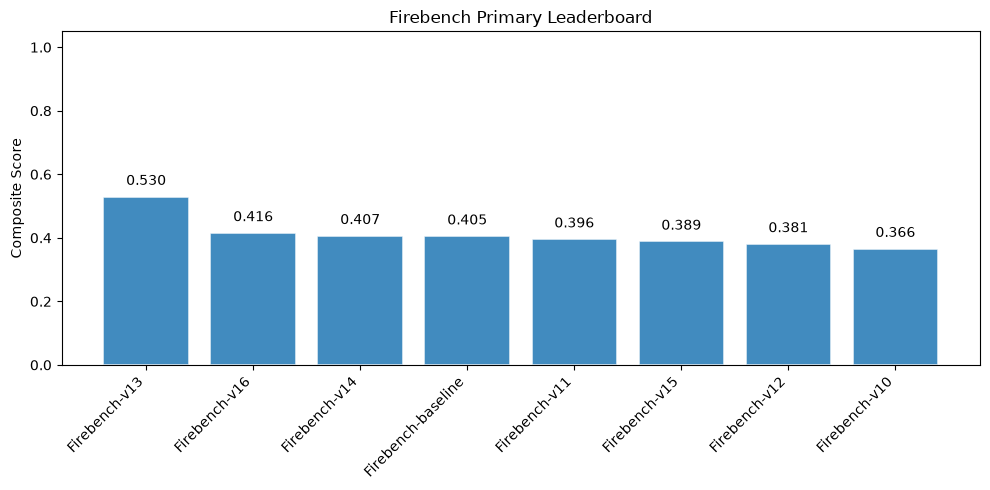

In [13]:
primary_df = render_single_benchmark_leaderboard(
    base_path=base_path,
    benchmark=current_benchmark,
    min_version=min_version,
    mode="primary",
    metric_weights=primary_metric_weights,
    display_fn=display,
)

## Primary + Diversity Leaderboard

Adds `Diversity@25` to the weighted score.


Firebench (Primary + Diversity):


,benchmark,system_version,query_count,MRR,Success@25,Precision@25,NDCG@25,Recall@25,Diversity@25,composite_score,rank_within_benchmark
0,Firebench,v13,100,0.299670,0.76,0.0792,0.389085,0.131868,0.235998,0.431889,1
1,Firebench,v16,100,0.211571,0.62,0.0568,0.309803,0.101316,0.280689,0.370753,2
2,Firebench,v14,100,0.213233,0.60,0.0512,0.295797,0.092783,0.282136,0.365123,3
3,Firebench,v15,100,0.207745,0.57,0.0472,0.288703,0.081636,0.288331,0.355359,4
4,Firebench,v11,100,0.181919,0.61,0.0544,0.271619,0.099311,0.255128,0.349016,5
5,Firebench,v12,100,0.132046,0.63,0.0608,0.248102,0.111765,0.256171,0.339406,6
6,Firebench,v10,100,0.172188,0.56,0.0592,0.249263,0.108901,0.244647,0.325612,7
7,Firebench,baseline,100,0.170756,0.64,0.0636,0.265473,0.096295,0.122002,0.310919,8


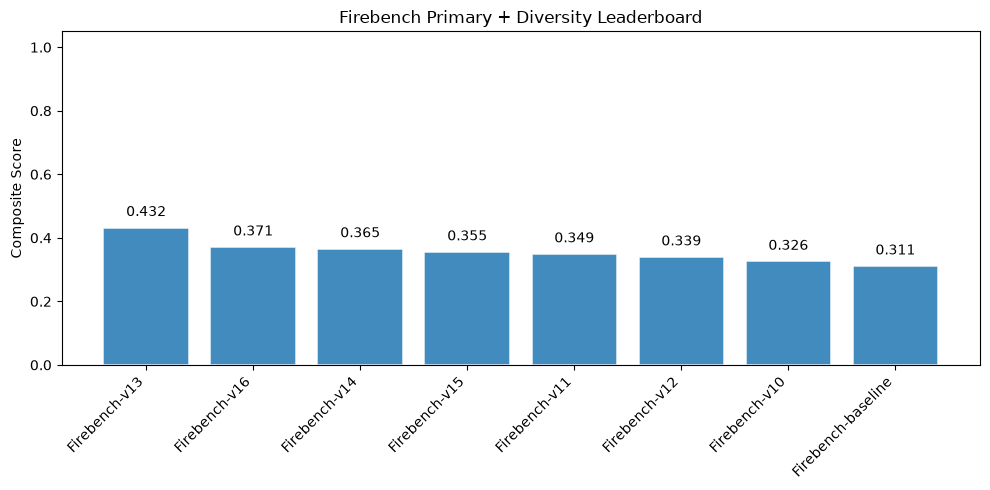

In [14]:
primary_plus_diversity_df = render_single_benchmark_leaderboard(
    base_path=base_path,
    benchmark=current_benchmark,
    min_version=min_version,
    mode="primary_plus_diversity",
    metric_weights=primary_plus_diversity_metric_weights,
    display_fn=display,
)

## Primary Leaderboard (with Ablation Studies)

Same weighted composite as the primary leaderboard (`MRR`, `Success@25`), but also includes `ablation_*` result folders when present.



Firebench (Primary (with Ablation Studies)):


,benchmark,system_version,query_count,MRR,Success@25,Precision@25,NDCG@25,Recall@25,Diversity@25,composite_score,rank_within_benchmark
0,Firebench,v13,100,0.299670,0.76,0.0792,0.389085,0.131868,0.235998,0.529835,1
1,Firebench,ablation_img_only,100,0.203424,0.68,0.0732,0.288897,0.127553,0.145383,0.441712,2
2,Firebench,ablation_vec_only,100,0.190846,0.65,0.0748,0.282582,0.137495,0.163282,0.420423,3
3,Firebench,v16,100,0.211571,0.62,0.0568,0.309803,0.101316,0.280689,0.415785,4
4,Firebench,v14,100,0.213233,0.60,0.0512,0.295797,0.092783,0.282136,0.406617,5
5,Firebench,baseline,100,0.170756,0.64,0.0636,0.265473,0.096295,0.122002,0.405378,6
6,Firebench,v11,100,0.181919,0.61,0.0544,0.271619,0.099311,0.255128,0.395960,7
7,Firebench,v15,100,0.207745,0.57,0.0472,0.288703,0.081636,0.288331,0.388873,8
8,Firebench,v12,100,0.132046,0.63,0.0608,0.248102,0.111765,0.256171,0.381023,9
9,Firebench,v10,100,0.172188,0.56,0.0592,0.249263,0.108901,0.244647,0.366094,10


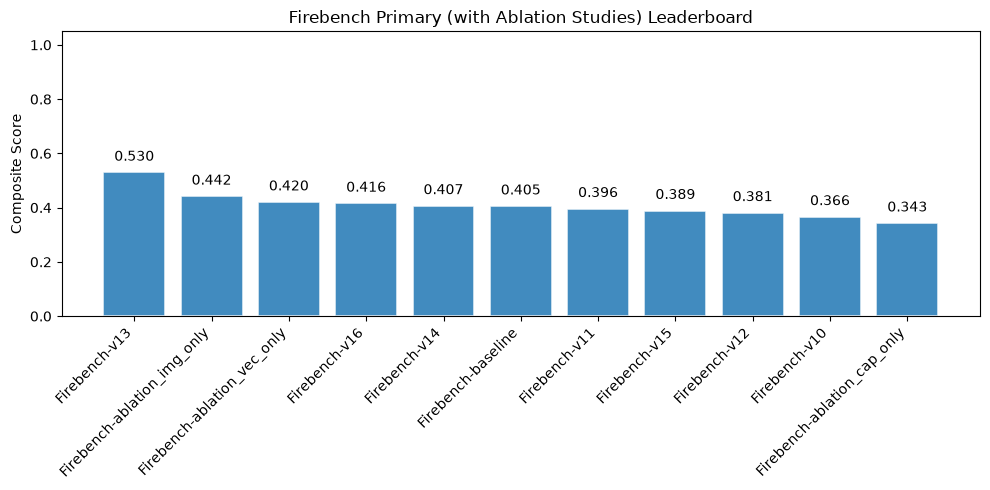

In [15]:
primary_ablation_df = render_single_benchmark_leaderboard(
    base_path=base_path,
    benchmark=current_benchmark,
    min_version=min_version,
    include_ablations=True,
    mode="primary",
    metric_weights=primary_metric_weights,
    display_fn=display,
)